In [13]:
# Linear Temp PyTorch Example for Reference #
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

t_un = (t_u - t_u.mean()) / t_u.std()

#5
w = torch.ones(())
b = torch.zeros(())
t_p = w * t_u + b
t_p

import torch.optim as optim
dir(optim)

params = torch.tensor([1.0, 0.0])
params

# Define optimizer
optimizer = optim.SGD([params], lr=1e-2)

def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [14]:
# Linear Temp PyTorch Example for Reference #
#7
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()
optimizer.step()
params


tensor([-44.1730,  -0.8260], requires_grad=True)

Epoch 500, Loss 2.927645
Epoch 1000, Loss 2.927645
Epoch 1500, Loss 2.927645
Epoch 2000, Loss 2.927645
Epoch 2500, Loss 2.927645
Epoch 3000, Loss 2.927645
Epoch 3500, Loss 2.927645
Epoch 4000, Loss 2.927645
Epoch 4500, Loss 2.927645
Epoch 5000, Loss 2.927645


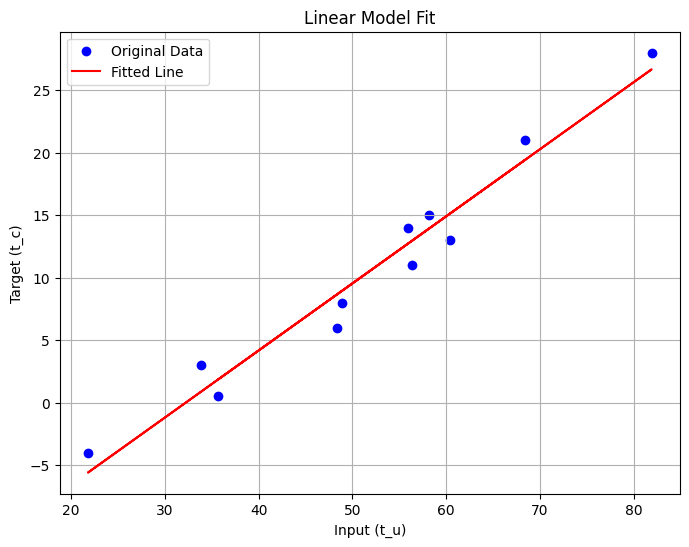

In [16]:
# Linear Temp PyTorch Example for Reference #
#9
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

#10
training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = params,
    t_u = t_un,
    t_c = t_c)

import matplotlib.pyplot as plt

# Generate predictions using the trained parameters
final_params = params.detach()  # Detach from the computation graph
final_w, final_b = final_params  # Extract the weight and bias
t_p_final = model(t_un, final_w, final_b)  # Predictions using normalized inputs

# Plot the original data and the model's predictions
plt.figure(figsize=(8, 6))
plt.scatter(t_u, t_c, color="blue", label="Original Data")  # Original data points
plt.plot(t_u, t_p_final.detach(), color="red", label="Fitted Line")  # Linear model's prediction line
plt.xlabel("Input (t_u)")
plt.ylabel("Target (t_c)")
plt.title("Linear Model Fit")
plt.legend()
plt.grid(True)
plt.show()


START HOMEWORK 5:

Problem 1

Epoch 500, Loss 60.483875
Epoch 1000, Loss 60.483875
Epoch 1500, Loss 60.483875
Epoch 2000, Loss 60.483875
Epoch 2500, Loss 60.483875
Epoch 3000, Loss 60.483875
Epoch 3500, Loss 60.483875
Epoch 4000, Loss 60.483875
Epoch 4500, Loss 60.483875
Epoch 5000, Loss 60.483875


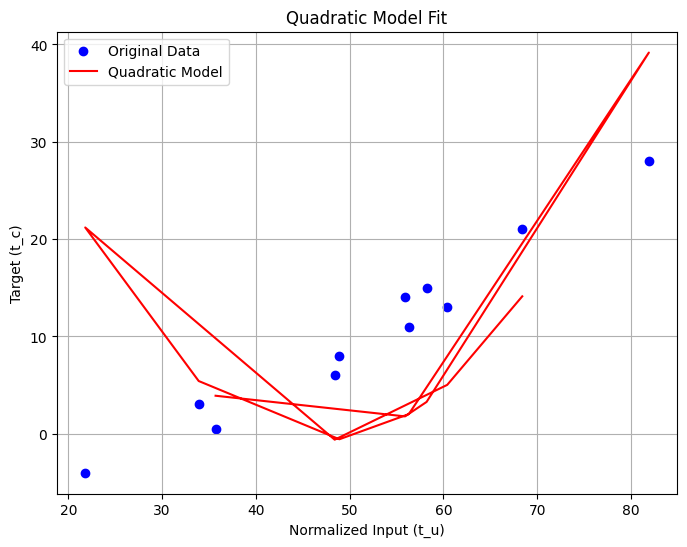

In [17]:
# Nonlinear System for Quadratic Model
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

t_un = (t_u - t_u.mean()) / t_u.std()

#5
w2 = torch.ones(())
w1 = torch.ones(())
b = torch.zeros(())
t_p = w2*t_u**2 + w1*t_u + b
t_p

import torch.optim as optim
dir(optim)

params = torch.tensor([1.0, 0.0])
params

# Define optimizer
optimizer = optim.SGD([params], lr=1e-3)

def model(t_u, w1, w2, b):
    return w2*t_u**2 + w1*t_u + b

def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

loss = loss_fn(t_p, t_c)
loss

params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_u, *params, b)
loss = loss_fn(t_p, t_c)
loss.backward()
optimizer.step()
params

def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params, b)
        loss = loss_fn(t_p, t_c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

training_loop(
    n_epochs = 5000,
    learning_rate = 1e-1,
    params = params,
    t_u = t_un,
    t_c = t_c)

import matplotlib.pyplot as plt

# Use final trained parameters
final_params = params.detach()
final_w2, final_w1 = final_params
final_b = b  # Bias remains constant

# Generate Final predictions
t_p_final = model(t_un, final_w1, final_w2, final_b)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(t_u.numpy(), t_c.numpy(), color="blue", label="Original Data")  # Original data points
plt.plot(t_u.numpy(), t_p_final.detach().numpy(), color="red", label="Quadratic Model")  # Model predictions
plt.xlabel("Normalized Input (t_u)")
plt.ylabel("Target (t_c)")
plt.title("Quadratic Model Fit")
plt.legend()
plt.grid(True)
plt.show()


Found best learning rate to be 0.1 with a final loss on the non-linear model of 60.483875 on Epoch 5000.

Problem 2

In [5]:
# Import necessary libraries
import pandas as pd
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/My Drive/Housing.csv')

# Select the input features and target column
input_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
output_column = 'price'

X = df[input_columns].values  # Convert input columns to NumPy array
y = df[output_column].values  # Convert output column to NumPy array

# Normalize the input features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
Xn = (X - X_mean) / X_std  # Normalized features

# Normalize the target variable (y)
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std  # Normalized target

# Convert the data to PyTorch tensors
X_tensor = torch.tensor(Xn, dtype=torch.float32)
y_tensor = torch.tensor(y_normalized, dtype=torch.float32).unsqueeze(1)  # Add dimension for 2D output

# Split the data into training and test sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)

# Define the model
def model(X, w, b):
    return X @ w + b  # Linear model: X * w + b

# Define the loss function (Mean Squared Error)
def loss_fn(t_p, y):
    return ((t_p - y) ** 2).mean()

# Define the training loop
def training_loop(n_epochs, optimizer, w, b, X_train, y_train):
    for epoch in range(1, n_epochs + 1):
        t_p = model(X_train, w, b)  # Predictions
        loss = loss_fn(t_p, y_train)  # Compute loss

        optimizer.zero_grad()  # Zero gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)
# Define optimizer
learning_rate = 1e-3
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-3")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)
# Define optimizer
learning_rate = 1e-2
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-2")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)
# Define optimizer
learning_rate = 1e-1
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-1")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

Mounted at /content/drive

New Learning Rate = 1e-3
Epoch 1, Loss: 4.0771
Epoch 500, Loss: 1.5406
Epoch 1000, Loss: 1.0570
Epoch 1500, Loss: 0.9348
Epoch 2000, Loss: 0.8991
Epoch 2500, Loss: 0.8880
Epoch 3000, Loss: 0.8846
Epoch 3500, Loss: 0.8835
Epoch 4000, Loss: 0.8831
Epoch 4500, Loss: 0.8830
Epoch 5000, Loss: 0.8830

New Learning Rate = 1e-2
Epoch 1, Loss: 5.3895
Epoch 500, Loss: 0.8830
Epoch 1000, Loss: 0.8830
Epoch 1500, Loss: 0.8830
Epoch 2000, Loss: 0.8830
Epoch 2500, Loss: 0.8830
Epoch 3000, Loss: 0.8830
Epoch 3500, Loss: 0.8830
Epoch 4000, Loss: 0.8830
Epoch 4500, Loss: 0.8830
Epoch 5000, Loss: 0.8830

New Learning Rate = 1e-1
Epoch 1, Loss: 4.7999
Epoch 500, Loss: 0.8830
Epoch 1000, Loss: 0.8830
Epoch 1500, Loss: 0.8830
Epoch 2000, Loss: 0.8830
Epoch 2500, Loss: 0.8830
Epoch 3000, Loss: 0.8830
Epoch 3500, Loss: 0.8830
Epoch 4000, Loss: 0.8830
Epoch 4500, Loss: 0.8830
Epoch 5000, Loss: 0.8830


Problem 3: Housing dataset with all features

In [10]:
# Import necessary libraries
import pandas as pd
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
pd.set_option('future.no_silent_downcasting', True)

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/My Drive/Housing.csv')

# Map Yes to 1 and No to 0
df = df.replace({'yes': 1, 'no': 0}).astype({'mainroad': int, 'guestroom': int, 'basement': int, 'hotwaterheating': int, 'airconditioning': int, 'prefarea': int})

# Convert 'furnishingstatus' to integers explicitly
df['furnishingstatus'] = df['furnishingstatus'].replace({'furnished': 0, 'semi-furnished': 1, 'unfurnished': 2}).astype(int)


# Select the input features and target column
input_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
output_column = 'price'

X = df[input_columns].values  # Convert input columns to NumPy array
y = df[output_column].values  # Convert output column to NumPy array

# Normalize the input features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
Xn = (X - X_mean) / X_std  # Normalized features

# Normalize the target variable (y)
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std  # Normalized target

# Convert the data to PyTorch tensors
X_tensor = torch.tensor(Xn, dtype=torch.float32)
y_tensor = torch.tensor(y_normalized, dtype=torch.float32).unsqueeze(1)  # Add dimension for 2D output

# Split the data into training and test sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)

# Define the model
def model(X, w, b):
    return X @ w + b  # Linear model: X * w + b

# Define the loss function (Mean Squared Error)
def loss_fn(t_p, y):
    return ((t_p - y) ** 2).mean()

# Define the training loop
def training_loop(n_epochs, optimizer, w, b, X_train, y_train):
    for epoch in range(1, n_epochs + 1):
        t_p = model(X_train, w, b)  # Predictions
        loss = loss_fn(t_p, y_train)  # Compute loss

        optimizer.zero_grad()  # Zero gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Define optimizer
learning_rate = 1e-3
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-3")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)
# Define optimizer
learning_rate = 1e-2
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-2")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

# Initialize weights and bias
w = torch.randn(X_train.shape[1], requires_grad=True)  # Random initialization
b = torch.tensor(0.0, requires_grad=True)
# Define optimizer
learning_rate = 1e-1
optimizer = optim.SGD([w, b], lr=learning_rate)

print("\nNew Learning Rate = 1e-1")

# Train the model
training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    w=w,
    b=b,
    X_train=X_train,
    y_train=y_train
)

# Evaluate the model on the test set
with torch.no_grad():
    y_pred = model(X_test, w, b)  # Predictions on test set
    y_pred = y_pred * y_std + y_mean  # Reverse normalization for predictions
    y_test_actual = y_test * y_std + y_mean  # Reverse normalization for actual values

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

New Learning Rate = 1e-3
Epoch 1, Loss: 12.1600
Epoch 500, Loss: 3.0561
Epoch 1000, Loss: 1.3672
Epoch 1500, Loss: 0.9961
Epoch 2000, Loss: 0.9103
Epoch 2500, Loss: 0.8897
Epoch 3000, Loss: 0.8847
Epoch 3500, Loss: 0.8834
Epoch 4000, Loss: 0.8831
Epoch 4500, Loss: 0.8830
Epoch 5000, Loss: 0.8830

New Learning Rate = 1e-2
Epoch 1, Loss: 8.0421
Epoch 500, Loss: 0.8830
Epoch 1000, Loss: 0.8830
Epoch 1500, Loss: 0.8830
Epoch 2000, Loss: 0.8830
Epoch 2500, Loss: 0.8830
Epoch 3000, Loss: 0.8830
Epoch 3500, Loss: 0.8830
Epoch 4000, Loss: 0.8830
Epoch 4500, Loss: 0.8830
Epoch 5000, Loss: 0.8830

New Learning Rate = 1e-1
Epoch 1, Loss: 12.0976
Epoch 500, Loss: 0.8830
Epoch 1000, Loss: 0.8830
Epoch 1500, Loss: 0.8830
Epoch 2000, Loss: 0.8830
Epoch 2500, Loss: 0.8830
Epoch 3000, Loss: 0.8830
Epoch 3500, Loss: 0.8830
Epoch 4000, Loss: 0.8830
Epoch 4500, Loss: 0.8830
Epo